In [1]:
from apeGmsh import apeGmsh
import numpy as np
from matplotlib import pyplot as plt
import gmsh
from pathlib import Path
from matplotlib.collections import PolyCollection
import openseespy.opensees as ops
import pandas as pd

# Plate Example

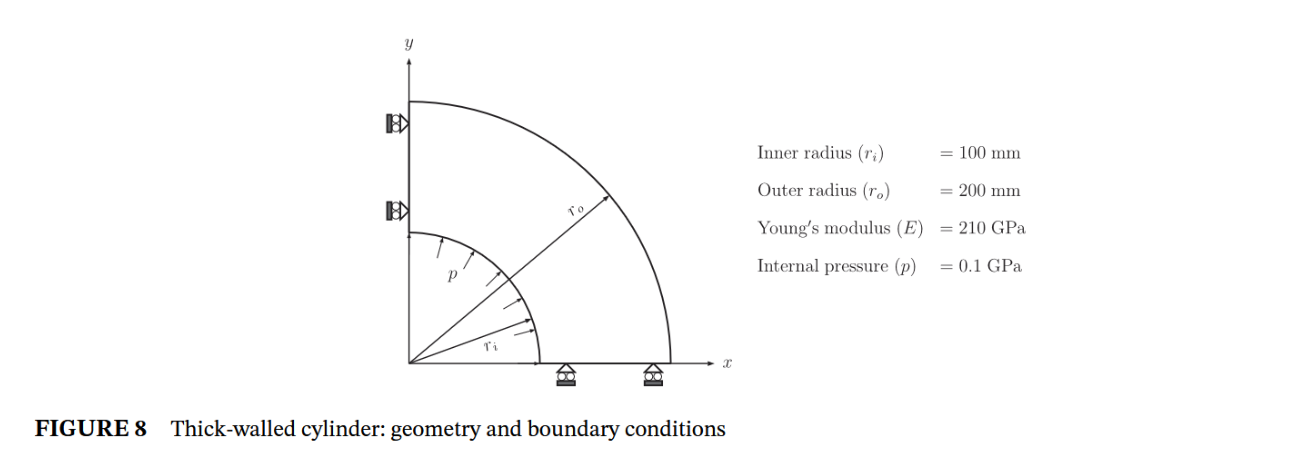

Given the plate, we will solve the 

In [2]:
# ============================================================
# Parameters
# ============================================================
inner_radius = 100.0    # mm
outer_radius = 200.0    # mm
lc           = 10.0     # mesh size [mm]

E   = 210.0e3   # Young's modulus [MPa]  (210 GPa)
nu  = 0.3       # Poisson's ratio
p   = 100.0     # internal pressure [MPa] (0.1 GPa)
thk = 1.0       # unit thickness for plane strain

Total nodes from Gmsh: 333
Element type 2 (Triangle 3): 594 elements, 3 nodes/elem
Connectivity shape: (594, 3)
Nodes actually used by elements: 332

Boundary nodes — x-axis (uy=0): 11
Boundary nodes — y-axis (ux=0): 11
Inner arc nodes (pressure):      17
Inner arc edges:                  16

OpenSees nodes created: 332 (skipped 1 orphan nodes)
OpenSees tri31 elements created: 594
Pressure loads applied to 17 inner-arc nodes

*** Analysis CONVERGED ***

σ_xx range: [-101.6486, 176.5394] MPa
σ_yy range: [-102.1127, 178.7372] MPa

Max radial displacement: 0.090498 mm
Min radial displacement: 0.000000 mm


Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


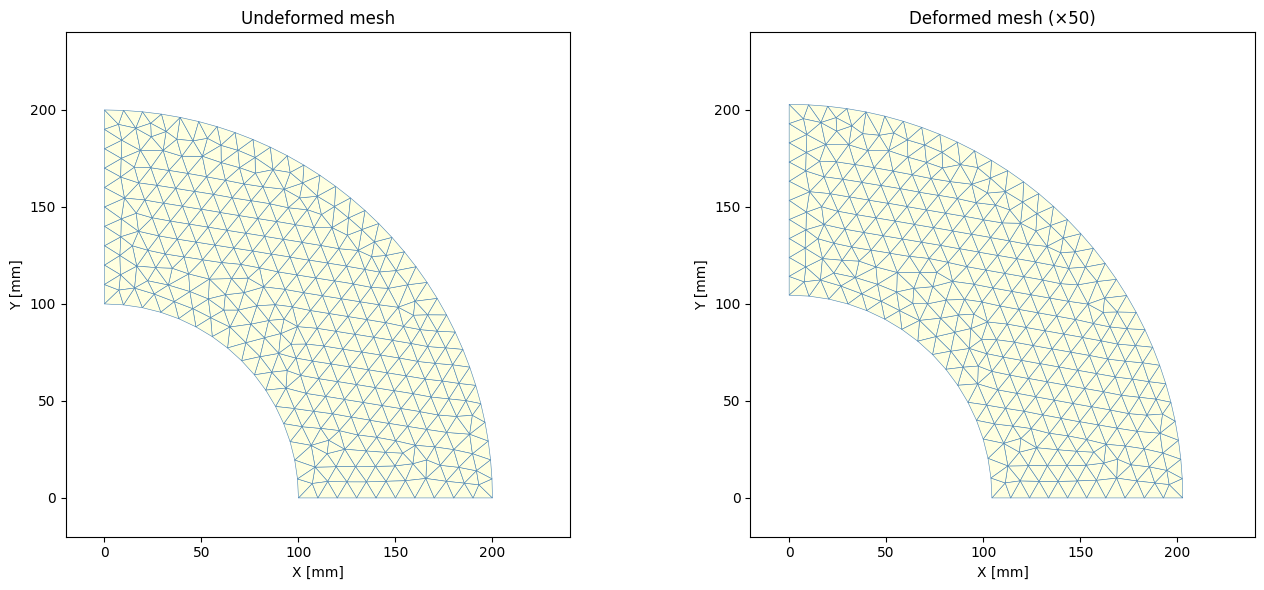

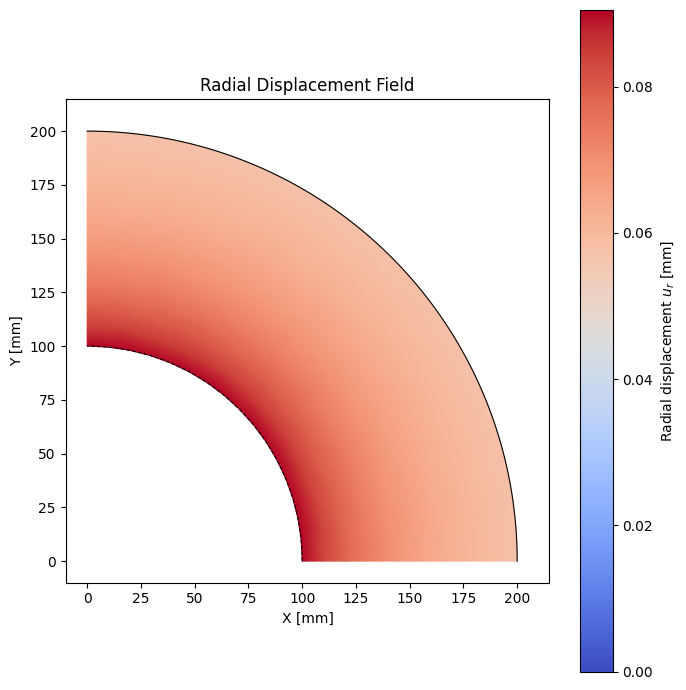

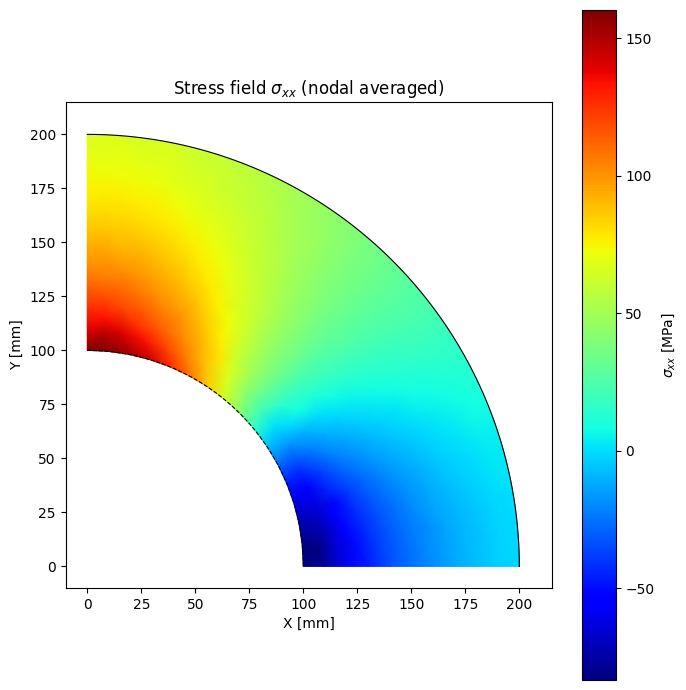

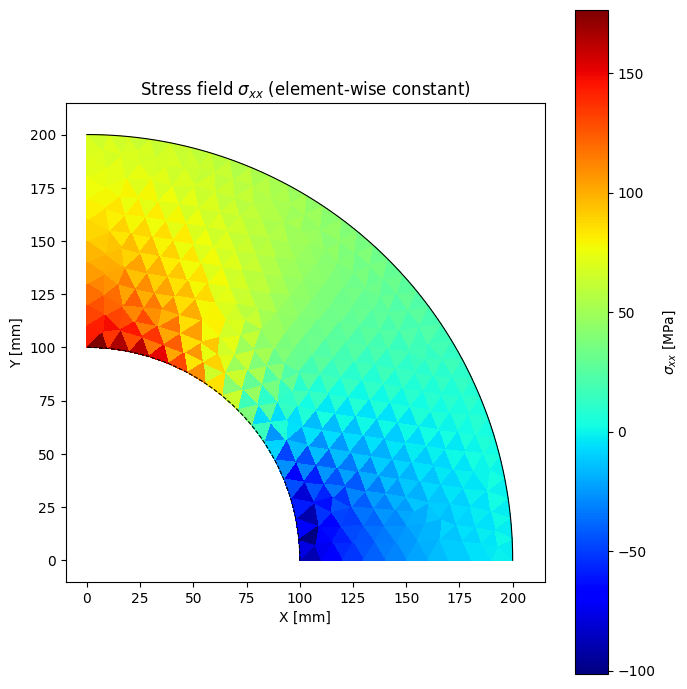


Done.


In [ ]:
"""
Thick-Walled Cylinder — Quarter Model (Lamé Problem)
=====================================================
Gmsh mesh → OpenSeesPy tri31 plane-strain model

Geometry & Material:
    ri = 100 mm,  ro = 200 mm
    E  = 210 GPa, ν  = 0.3
    p  = 0.1 GPa  (internal pressure)

Boundary conditions (symmetry):
    x-axis (bottom)  →  uy = 0
    y-axis (left)    →  ux = 0
    inner arc         →  internal pressure (radially outward)
"""

gmsh.initialize()
gmsh.model.add("Plate2D")

# Center point (needed as 2nd argument in addCircleArc)
pc = gmsh.model.geo.addPoint(0, 0, 0, lc)

# 4 corner points
p1 = gmsh.model.geo.addPoint(inner_radius, 0, 0, lc)     # inner, x-axis
p2 = gmsh.model.geo.addPoint(outer_radius, 0, 0, lc)     # outer, x-axis
p3 = gmsh.model.geo.addPoint(0, outer_radius, 0, lc)     # outer, y-axis
p4 = gmsh.model.geo.addPoint(0, inner_radius, 0, lc)     # inner, y-axis

# 2 radial lines + 2 circular arcs
l1 = gmsh.model.geo.addLine(p1, p2)                       # bottom (x-axis)
l2 = gmsh.model.geo.addCircleArc(p2, pc, p3)              # outer arc CCW
l3 = gmsh.model.geo.addLine(p3, p4)                       # left   (y-axis)
l4 = gmsh.model.geo.addCircleArc(p4, pc, p1)              # inner arc CCW

# Surface
s1_loop = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
s1      = gmsh.model.geo.addPlaneSurface([s1_loop])

# Synchronize ONCE before physical groups and meshing
gmsh.model.geo.synchronize()

# Physical groups — capture returned tags for reliable extraction later
#   l1 = bottom edge (x-axis)  → fix uy (symmetry)
#   l3 = left edge   (y-axis)  → fix ux (symmetry)
#   l4 = inner arc             → pressure load
pg_symY     = gmsh.model.addPhysicalGroup(1, [l1], name="Sym_Y")      # uy = 0
pg_symX     = gmsh.model.addPhysicalGroup(1, [l3], name="Sym_X")      # ux = 0
pg_pressure = gmsh.model.addPhysicalGroup(1, [l4], name="Pressure")   # inner pressure
pg_plate    = gmsh.model.addPhysicalGroup(2, [s1], name="Plate")

# Mesh settings
gmsh.option.setNumber("Mesh.Algorithm", 6)       # Frontal-Delaunay
gmsh.option.setNumber("Mesh.ElementOrder", 1)     # linear triangles
gmsh.option.setNumber("Mesh.MeshSizeMin", lc * 0.5)
gmsh.option.setNumber("Mesh.MeshSizeMax", lc)

# Generate 2D mesh
gmsh.model.mesh.generate(2)

# ============================================================
# Extract mesh data from Gmsh
# ============================================================

# --- All nodes ---
node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
node_coords = node_coords.reshape(-1, 3)
tag_to_idx = {int(t): i for i, t in enumerate(node_tags)}

print(f"Total nodes from Gmsh: {len(node_tags)}")

# --- 2D elements (triangles) ---
elem_types, elem_tags, elem_node_tags = gmsh.model.mesh.getElements(dim=2)

tri_conn = []
for etype, etags, enodes in zip(elem_types, elem_tags, elem_node_tags):
    name, dim, order, nnodes, _, _ = gmsh.model.mesh.getElementProperties(etype)
    print(f"Element type {etype} ({name}): {len(etags)} elements, {nnodes} nodes/elem")
    tri_conn.append(enodes.reshape(-1, nnodes).astype(int))

connectivity = np.vstack(tri_conn)
print(f"Connectivity shape: {connectivity.shape}")

# --- Filter: only keep nodes that are referenced by elements ---
#     The geometric center point pc at (0,0) gets a mesh node from Gmsh
#     but no triangle connects to it. Sending it to OpenSees would create
#     a zero-stiffness node → singular matrix.
used_tags = set(connectivity.flatten())
print(f"Nodes actually used by elements: {len(used_tags)}")

# --- Boundary nodes from physical groups (using captured tags) ---
bottom_node_tags = gmsh.model.mesh.getNodesForPhysicalGroup(1, pg_symY)[0]      # uy = 0
left_node_tags   = gmsh.model.mesh.getNodesForPhysicalGroup(1, pg_symX)[0]      # ux = 0
inner_node_tags  = gmsh.model.mesh.getNodesForPhysicalGroup(1, pg_pressure)[0]  # pressure

# --- Inner arc edges: get 2-node line elements on the pressure boundary ---
inner_elem_types, inner_elem_tags, inner_elem_nodes = \
    gmsh.model.mesh.getElements(dim=1, tag=l4)

inner_edges = []
for etype, etags, enodes in zip(inner_elem_types, inner_elem_tags, inner_elem_nodes):
    _, _, _, nnodes, _, _ = gmsh.model.mesh.getElementProperties(etype)
    inner_edges = enodes.reshape(-1, nnodes).astype(int)

print(f"\nBoundary nodes — x-axis (uy=0): {len(bottom_node_tags)}")
print(f"Boundary nodes — y-axis (ux=0): {len(left_node_tags)}")
print(f"Inner arc nodes (pressure):      {len(inner_node_tags)}")
print(f"Inner arc edges:                  {len(inner_edges)}")

# NOTE: do NOT finalize Gmsh here — we will inject OpenSees results
# as post-processing views and launch the GUI at the end.
print("\n[Gmsh kept alive for post-processing views]")

# ============================================================
# PART 2 — OpenSeesPy: Build the FEM model
# ============================================================
ops.wipe()
ops.model("basic", "-ndm", 2, "-ndf", 2)   # 2D, 2 DOF/node (plane strain)

# --- Nodes ---
# Gmsh tags may not be contiguous → remap to sequential 1-based IDs
# IMPORTANT: only create nodes that appear in the element connectivity.
# The geometric center point pc at (0,0) produces an orphan mesh node
# in Gmsh — including it here would give a zero-stiffness DOF and a
# singular stiffness matrix.
gmsh_to_ops = {}
new_id = 0
for gtag, coords in zip(node_tags.astype(int), node_coords):
    if int(gtag) not in used_tags:
        continue                     # skip orphan nodes
    new_id += 1
    gmsh_to_ops[int(gtag)] = new_id
    ops.node(new_id, float(coords[0]), float(coords[1]))

print(f"\nOpenSees nodes created: {len(gmsh_to_ops)} "
      f"(skipped {len(node_tags) - len(gmsh_to_ops)} orphan nodes)")

# --- Material ---
mat_tag = 1
ops.nDMaterial("ElasticIsotropic", mat_tag, E, nu)

# --- Elements (tri31) ---
#   element('tri31', eleTag, *[iNode, jNode, kNode], thick, type, matTag)
for eid, row in enumerate(connectivity, start=1):
    n1 = gmsh_to_ops[row[0]]
    n2 = gmsh_to_ops[row[1]]
    n3 = gmsh_to_ops[row[2]]
    ops.element("tri31", eid, n1, n2, n3,
                thk, "PlaneStrain", mat_tag)

print(f"OpenSees tri31 elements created: {connectivity.shape[0]}")

# --- Boundary conditions (symmetry) ---
# x-axis: fix uy (DOF 2)
for gtag in bottom_node_tags.astype(int):
    ops.fix(gmsh_to_ops[int(gtag)], 0, 1)

# y-axis: fix ux (DOF 1)
for gtag in left_node_tags.astype(int):
    ops.fix(gmsh_to_ops[int(gtag)], 1, 0)

# Corner node at origin would be on both axes — if it exists, fix both
# (handled automatically since it appears in both groups)

# --- Pressure load on inner arc ---
#
#   For internal pressure on a curved boundary, we compute
#   equivalent nodal forces by integrating  t = p · n_hat  over
#   each boundary edge, where n_hat = (cos θ, sin θ) points
#   radially outward at each point on the inner arc.
#
#   For a 2-node edge (linear shape functions) of length L:
#     F_i = (L/6) · (2·t_i + t_j)
#     F_j = (L/6) · (t_i + 2·t_j)

ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)

# Accumulate nodal forces (a node may be shared by two edges)
nodal_forces = {}  # ops_node_id → [Fx, Fy]

for edge in inner_edges:
    n1_gmsh, n2_gmsh = int(edge[0]), int(edge[1])
    idx1, idx2 = tag_to_idx[n1_gmsh], tag_to_idx[n2_gmsh]

    x1, y1 = node_coords[idx1, 0], node_coords[idx1, 1]
    x2, y2 = node_coords[idx2, 0], node_coords[idx2, 1]

    # Edge length
    L = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    # Outward radial normal at each node (unit vector from origin)
    r1 = np.sqrt(x1**2 + y1**2)
    r2 = np.sqrt(x2**2 + y2**2)
    nx1, ny1 = x1 / r1, y1 / r1
    nx2, ny2 = x2 / r2, y2 / r2

    # Traction at each node: t = p * n_hat
    tx1, ty1 = p * nx1, p * ny1
    tx2, ty2 = p * nx2, p * ny2

    # Equivalent nodal forces (consistent, linear shape functions)
    Fx1 = (L / 6.0) * (2.0 * tx1 + tx2)
    Fy1 = (L / 6.0) * (2.0 * ty1 + ty2)
    Fx2 = (L / 6.0) * (tx1 + 2.0 * tx2)
    Fy2 = (L / 6.0) * (ty1 + 2.0 * ty2)

    ops_n1 = gmsh_to_ops[n1_gmsh]
    ops_n2 = gmsh_to_ops[n2_gmsh]

    nodal_forces.setdefault(ops_n1, [0.0, 0.0])
    nodal_forces.setdefault(ops_n2, [0.0, 0.0])
    nodal_forces[ops_n1][0] += Fx1
    nodal_forces[ops_n1][1] += Fy1
    nodal_forces[ops_n2][0] += Fx2
    nodal_forces[ops_n2][1] += Fy2

for nid, (fx, fy) in nodal_forces.items():
    ops.load(nid, fx, fy)

print(f"Pressure loads applied to {len(nodal_forces)} inner-arc nodes")

# ============================================================
# PART 3 — Analysis
# ============================================================
ops.constraints("Transformation")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.test("NormDispIncr", 1.0e-8, 10)
ops.algorithm("Newton")
ops.integrator("LoadControl", 1.0)
ops.analysis("Static")

ok = ops.analyze(1)
if ok == 0:
    print("\n*** Analysis CONVERGED ***")
else:
    print("\n*** Analysis FAILED ***")

# ============================================================
# PART 4 — Post-processing: plot deformed shape & displacements
# ============================================================

# Gather displacements
# Size against the full Gmsh node array since tag_to_idx maps into it
disp = np.zeros((len(node_tags), 2))
for gtag, ops_id in gmsh_to_ops.items():
    idx = tag_to_idx[gtag]
    disp[idx, 0] = ops.nodeDisp(ops_id, 1)
    disp[idx, 1] = ops.nodeDisp(ops_id, 2)

# Radial displacement at each node: ur = (x·ux + y·uy) / r
r_nodes = np.sqrt(node_coords[:, 0]**2 + node_coords[:, 1]**2)
r_nodes_safe = np.where(r_nodes > 1e-12, r_nodes, 1.0)   # avoid /0 at origin
ur = (node_coords[:, 0] * disp[:, 0] + node_coords[:, 1] * disp[:, 1]) / r_nodes_safe

# --- Element stresses ---
# tri31 (constant-strain triangle) returns [σ_xx, σ_yy, σ_xy] per element
nElem = connectivity.shape[0]
sig_xx_elem = np.zeros(nElem)
sig_yy_elem = np.zeros(nElem)
sig_xy_elem = np.zeros(nElem)

for eid in range(1, nElem + 1):
    stress = ops.eleResponse(eid, "stresses")
    # tri31 returns [sxx, syy, sxy] (one Gauss point, constant over element)
    sig_xx_elem[eid - 1] = stress[0]
    sig_yy_elem[eid - 1] = stress[1]
    sig_xy_elem[eid - 1] = stress[2]

print(f"\nσ_xx range: [{sig_xx_elem.min():.4f}, {sig_xx_elem.max():.4f}] MPa")
print(f"σ_yy range: [{sig_yy_elem.min():.4f}, {sig_yy_elem.max():.4f}] MPa")

# --- Nodal averaging of element stresses (for smooth contours) ---
# Each node accumulates stress from surrounding elements, then divides
# by the count to get a smoothed nodal value.
conn_idx = np.array([[tag_to_idx[n] for n in row] for row in connectivity])

sig_xx_nodal = np.zeros(len(node_tags))
node_count   = np.zeros(len(node_tags))

for e in range(nElem):
    for local_n in range(3):
        nidx = conn_idx[e, local_n]
        sig_xx_nodal[nidx] += sig_xx_elem[e]
        node_count[nidx]   += 1.0

node_count[node_count == 0] = 1.0   # avoid /0 for orphan node
sig_xx_nodal /= node_count

print(f"\nMax radial displacement: {np.max(ur):.6f} mm")
print(f"Min radial displacement: {np.min(ur):.6f} mm")

# ---- Plot 1: Deformed mesh ----
scale = 50.0   # magnification factor for deformed shape
deformed_coords = node_coords[:, :2] + scale * disp

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, coords, title in zip(
        axes,
        [node_coords[:, :2], deformed_coords],
        ["Undeformed mesh", f"Deformed mesh (×{scale:.0f})"]):

    conn_idx = np.array([[tag_to_idx[n] for n in row] for row in connectivity])
    verts = coords[conn_idx]
    poly = PolyCollection(verts, edgecolors="steelblue",
                           facecolors="lightyellow", linewidths=0.4)
    ax.add_collection(poly)
    ax.set_xlim(-20, outer_radius + 40)
    ax.set_ylim(-20, outer_radius + 40)
    ax.set_aspect("equal")
    ax.set_xlabel("X [mm]")
    ax.set_ylabel("Y [mm]")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("thick_cylinder_deformed.png", dpi=150)
plt.show()

# ---- Plot 2: Radial displacement contour ----
fig, ax = plt.subplots(figsize=(7, 7))
conn_idx = np.array([[tag_to_idx[n] for n in row] for row in connectivity])
triplt = ax.tripcolor(node_coords[:, 0], node_coords[:, 1],
                       conn_idx, ur, shading="gouraud", cmap="coolwarm")
cb = plt.colorbar(triplt, ax=ax, label="Radial displacement $u_r$ [mm]")

theta = np.linspace(0, np.pi / 2, 100)
ax.plot(inner_radius * np.cos(theta), inner_radius * np.sin(theta), "k--", lw=0.8)
ax.plot(outer_radius * np.cos(theta), outer_radius * np.sin(theta), "k-",  lw=0.8)

ax.set_xlim(-10, outer_radius + 15)
ax.set_ylim(-10, outer_radius + 15)
ax.set_aspect("equal")
ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_title("Radial Displacement Field")
plt.tight_layout()
plt.savefig("thick_cylinder_ur_contour.png", dpi=150)
plt.show()

# ---- Plot 3: σ_xx contour (nodal-averaged, smooth) ----
fig, ax = plt.subplots(figsize=(7, 7))
triplt = ax.tripcolor(node_coords[:, 0], node_coords[:, 1],
                       conn_idx, sig_xx_nodal, shading="gouraud", cmap="jet")
plt.colorbar(triplt, ax=ax, label=r"$\sigma_{xx}$ [MPa]")

theta = np.linspace(0, np.pi / 2, 100)
ax.plot(inner_radius * np.cos(theta), inner_radius * np.sin(theta), "k--", lw=0.8)
ax.plot(outer_radius * np.cos(theta), outer_radius * np.sin(theta), "k-",  lw=0.8)

ax.set_xlim(-10, outer_radius + 15)
ax.set_ylim(-10, outer_radius + 15)
ax.set_aspect("equal")
ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_title(r"Stress field $\sigma_{xx}$ (nodal averaged)")
plt.tight_layout()
plt.savefig("thick_cylinder_sigxx.png", dpi=150)
plt.show()

# ---- Plot 4: σ_xx element-wise (piecewise constant, no averaging) ----
fig, ax = plt.subplots(figsize=(7, 7))
triplt = ax.tripcolor(node_coords[:, 0], node_coords[:, 1],
                       conn_idx, facecolors=sig_xx_elem, cmap="jet")
plt.colorbar(triplt, ax=ax, label=r"$\sigma_{xx}$ [MPa]")

ax.plot(inner_radius * np.cos(theta), inner_radius * np.sin(theta), "k--", lw=0.8)
ax.plot(outer_radius * np.cos(theta), outer_radius * np.sin(theta), "k-",  lw=0.8)

ax.set_xlim(-10, outer_radius + 15)
ax.set_ylim(-10, outer_radius + 15)
ax.set_aspect("equal")
ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_title(r"Stress field $\sigma_{xx}$ (element-wise constant)")
plt.tight_layout()
plt.savefig("thick_cylinder_sigxx_elem.png", dpi=150)
plt.show()

ops.wipe()

# ============================================================
# PART 5 — Pass results to Gmsh as post-processing views
# ============================================================
#
# Gmsh's post-processing module (gmsh.view) lets you attach scalar,
# vector, or tensor fields to the mesh and visualize them in the GUI.
#
# Two key functions:
#
#   gmsh.view.addModelData(viewTag, step, modelName, dataType,
#                          tags, data, time, numComponents)
#
#     viewTag       — integer returned by gmsh.view.add()
#     step          — time step index (0 for static)
#     modelName     — name of the Gmsh model (must match gmsh.model.add())
#     dataType      — "ElementData" (1 value/element) or "NodeData" (1 value/node)
#     tags          — list of element tags (ElementData) or node tags (NodeData)
#     data          — list of lists: [[val1], [val2], ...] for scalars
#                     or [[vx, vy, vz], ...] for vectors
#     time          — time value for this step (0.0 for static)
#     numComponents — 1=scalar, 3=vector, 6=sym tensor, 9=full tensor
#

# We need the Gmsh element tags — we stored them earlier in elem_tags
# (from gmsh.model.mesh.getElements). These are the Gmsh-internal
# element IDs, NOT the OpenSees element IDs.
gmsh_elem_tags = []
for etags in elem_tags:
    gmsh_elem_tags.extend(etags.astype(int).tolist())

# Similarly, for NodeData we need the original Gmsh node tags.
gmsh_node_tags_used = [int(t) for t in node_tags if int(t) in used_tags]

# ---- View 1: σ_xx per element (ElementData) ----
v1 = gmsh.view.add("sigma_xx [MPa]")
gmsh.view.addModelData(
    v1,                           # view tag
    0,                            # step
    "Plate2D",                    # model name (must match gmsh.model.add)
    "ElementData",                # one value per element
    gmsh_elem_tags,               # Gmsh element tags
    [[float(s)] for s in sig_xx_elem],  # data: list of [scalar] per element
    0.0,                          # time
    1                             # numComponents = 1 (scalar)
)

# ---- View 2: σ_yy per element ----
v2 = gmsh.view.add("sigma_yy [MPa]")
gmsh.view.addModelData(
    v2, 0, "Plate2D", "ElementData",
    gmsh_elem_tags,
    [[float(s)] for s in sig_yy_elem],
    0.0, 1
)

# ---- View 3: σ_xy per element ----
v3 = gmsh.view.add("sigma_xy [MPa]")
gmsh.view.addModelData(
    v3, 0, "Plate2D", "ElementData",
    gmsh_elem_tags,
    [[float(s)] for s in sig_xy_elem],
    0.0, 1
)

# ---- View 4: Displacement vector (NodeData) ----
v4 = gmsh.view.add("Displacement [mm]")

disp_data = []
for gtag in gmsh_node_tags_used:
    idx = tag_to_idx[gtag]
    disp_data.append([float(disp[idx, 0]), float(disp[idx, 1]), 0.0])

gmsh.view.addModelData(
    v4, 0, "Plate2D", "NodeData",
    gmsh_node_tags_used,          # Gmsh node tags
    disp_data,                    # [ux, uy, uz] per node
    0.0, 3                        # numComponents = 3 (vector)
)

# ---- View 5: Radial displacement scalar (NodeData) ----
v5 = gmsh.view.add("u_r [mm]")

ur_data = []
for gtag in gmsh_node_tags_used:
    idx = tag_to_idx[gtag]
    ur_data.append([float(ur[idx])])

gmsh.view.addModelData(
    v5, 0, "Plate2D", "NodeData",
    gmsh_node_tags_used,
    ur_data,
    0.0, 1
)

# ---- View 6: σ_xx nodal-averaged (NodeData, smooth) ----
v6 = gmsh.view.add("sigma_xx nodal avg [MPa]")

sigxx_node_data = []
for gtag in gmsh_node_tags_used:
    idx = tag_to_idx[gtag]
    sigxx_node_data.append([float(sig_xx_nodal[idx])])

gmsh.view.addModelData(
    v6, 0, "Plate2D", "NodeData",
    gmsh_node_tags_used,
    sigxx_node_data,
    0.0, 1
)

# ---- Optional: set view options ----
# Use jet colormap range, show color bar
for v in [v1, v2, v3]:
    gmsh.view.option.setNumber(v, "IntervalsType", 3)   # continuous map
for v in [v4]:
    gmsh.view.option.setNumber(v, "VectorType", 5)      # displacement arrows

print(f"\nGmsh views created: {v6 + 1}")
print("Launching Gmsh GUI...")

# ---- Launch Gmsh GUI and finalize ----
gmsh.fltk.run()
gmsh.finalize()

print("\nDone.")

lc at addPoint — this is a local mesh size attached to each geometric vertex. It tells Gmsh "at this specific point, I want elements roughly this size." Gmsh then interpolates between vertices, so if one corner has lc=5 and a neighbor has lc=20, the mesh gradually transitions between those sizes across the surface. This is how you get local refinement — say, a finer mesh near the inner radius where stresses are higher, and coarser near the outer radius.

MeshSizeMin / MeshSizeMax — these are global clamps applied after all the local sizes are computed. They act as hard bounds. For example, if you set lc=10 at all points but MeshSizeMin=5, Gmsh won't create elements smaller than 5 mm even if its algorithm wanted to. Conversely, MeshSizeMax prevents elements from growing too large in regions far from any vertex.


  Mesh size lc = 40.0 mm
  Nodes: 31,  Elements: 42,  L2 error: 3.710671e-01

  Mesh size lc = 20.0 mm
  Nodes: 96,  Elements: 156,  L2 error: 2.034825e-01

  Mesh size lc = 10.0 mm
  Nodes: 332,  Elements: 594,  L2 error: 1.049563e-01

  Mesh size lc = 5.0 mm
  Nodes: 1200,  Elements: 2263,  L2 error: 5.097404e-02

  Mesh size lc = 2.5 mm
  Nodes: 4567,  Elements: 8863,  L2 error: 2.323962e-02

    h [mm]    Nodes   Elements      L2 error    Rate
      40.0       31         42  3.710671e-01    —
      20.0       96        156  2.034825e-01   0.87
      10.0      332        594  1.049563e-01   0.96
       5.0     1200       2263  5.097404e-02   1.04
       2.5     4567       8863  2.323962e-02   1.13


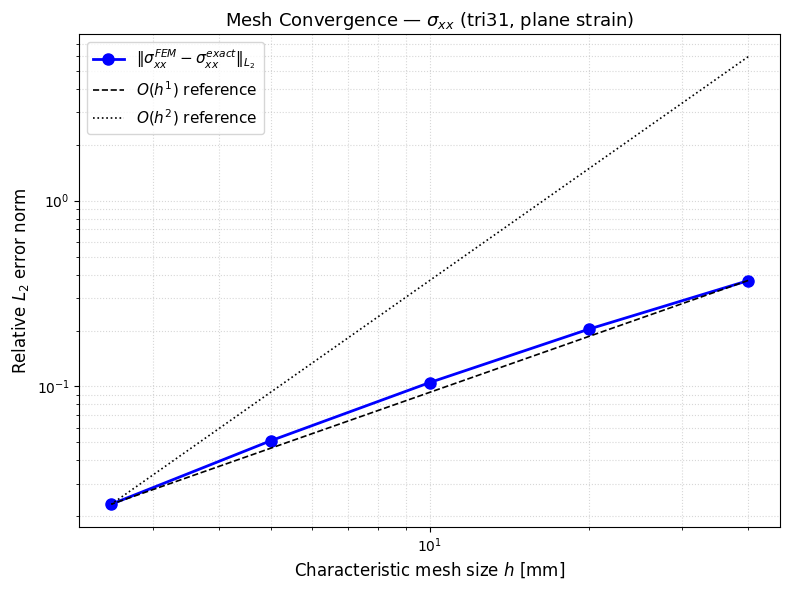


Done.


In [4]:
"""
Mesh Convergence Study — L2 Error Norm of σ_xx
================================================
Runs the thick-walled cylinder model at multiple mesh sizes,
computes the relative L2 error norm against the Lamé analytical
solution, and plots error vs h on a log-log scale.

L2 error norm (relative):

         ‖σ^FEM - σ^exact‖_L2       √( Σ_e  (σ_xx^e - σ_xx^exact(x_c))² · A_e )
  e  =  ────────────────────── =  ──────────────────────────────────────────────────
            ‖σ^exact‖_L2             √( Σ_e  (σ_xx^exact(x_c))² · A_e )

For CST (tri31): stress is constant per element, so the integral
reduces to a weighted sum over element areas.

Expected convergence: O(h^1) for stresses with linear triangles.
"""

# ============================================================
# Parameters
# ============================================================
inner_radius = 100.0    # mm
outer_radius = 200.0    # mm
E   = 210.0e3           # MPa
nu  = 0.3
p   = 100.0             # MPa
thk = 1.0               # mm

# Mesh sizes to test (coarse → fine)
lc_values = [40.0, 20.0, 10.0, 5.0, 2.5]


# ============================================================
# Lamé analytical solution (plane strain)
# ============================================================
def lame_stress_cartesian(x, y, ri, ro, p):
    """
    Returns (σ_xx, σ_yy, σ_xy) at point (x, y) from the
    Lamé closed-form solution for internal pressure.

    In polar coordinates:
        σ_rr(r) = A - B/r²
        σ_θθ(r) = A + B/r²
        σ_rθ    = 0

    where A = p·ri² / (ro² - ri²)
          B = p·ri²·ro² / (ro² - ri²)

    Transform to Cartesian:
        σ_xx = σ_rr·cos²θ + σ_θθ·sin²θ
        σ_yy = σ_rr·sin²θ + σ_θθ·cos²θ
        σ_xy = (σ_rr - σ_θθ)·sinθ·cosθ
    """
    r2 = x**2 + y**2
    r  = np.sqrt(r2)

    A = p * ri**2 / (ro**2 - ri**2)
    B = p * ri**2 * ro**2 / (ro**2 - ri**2)

    sig_rr = A - B / r2
    sig_tt = A + B / r2

    cos_t = x / r
    sin_t = y / r

    sig_xx = sig_rr * cos_t**2 + sig_tt * sin_t**2
    sig_yy = sig_rr * sin_t**2 + sig_tt * cos_t**2
    sig_xy = (sig_rr - sig_tt) * sin_t * cos_t

    return sig_xx, sig_yy, sig_xy


def triangle_area(x1, y1, x2, y2, x3, y3):
    """Area of a triangle from vertex coordinates."""
    return 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))


# ============================================================
# Convergence loop
# ============================================================
errors_L2  = []
h_values   = []
num_elems  = []
num_nodes  = []

for lc in lc_values:
    print(f"\n{'='*50}")
    print(f"  Mesh size lc = {lc} mm")
    print(f"{'='*50}")

    # ----------------------------------------------------------
    # GMSH: mesh generation
    # ----------------------------------------------------------
    gmsh.initialize()
    gmsh.model.add("Plate2D")

    pc = gmsh.model.geo.addPoint(0, 0, 0, lc)
    p1 = gmsh.model.geo.addPoint(inner_radius, 0, 0, lc)
    p2 = gmsh.model.geo.addPoint(outer_radius, 0, 0, lc)
    p3 = gmsh.model.geo.addPoint(0, outer_radius, 0, lc)
    p4 = gmsh.model.geo.addPoint(0, inner_radius, 0, lc)

    l1 = gmsh.model.geo.addLine(p1, p2)
    l2 = gmsh.model.geo.addCircleArc(p2, pc, p3)
    l3 = gmsh.model.geo.addLine(p3, p4)
    l4 = gmsh.model.geo.addCircleArc(p4, pc, p1)

    loop = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
    s1   = gmsh.model.geo.addPlaneSurface([loop])

    gmsh.model.geo.synchronize()

    pg_symY     = gmsh.model.addPhysicalGroup(1, [l1], name="Sym_Y")
    pg_symX     = gmsh.model.addPhysicalGroup(1, [l3], name="Sym_X")
    pg_pressure = gmsh.model.addPhysicalGroup(1, [l4], name="Pressure")
    pg_plate    = gmsh.model.addPhysicalGroup(2, [s1], name="Plate")

    gmsh.option.setNumber("Mesh.Algorithm", 6)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)
    gmsh.option.setNumber("Mesh.MeshSizeMin", lc * 0.5)
    gmsh.option.setNumber("Mesh.MeshSizeMax", lc)

    gmsh.model.mesh.generate(2)

    # Extract nodes
    node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
    node_coords = node_coords.reshape(-1, 3)
    tag_to_idx = {int(t): i for i, t in enumerate(node_tags)}

    # Extract triangles
    elem_types, elem_tags, elem_node_tags = gmsh.model.mesh.getElements(dim=2)
    tri_conn = []
    for etype, etags, enodes in zip(elem_types, elem_tags, elem_node_tags):
        _, _, _, nnodes, _, _ = gmsh.model.mesh.getElementProperties(etype)
        tri_conn.append(enodes.reshape(-1, nnodes).astype(int))
    connectivity = np.vstack(tri_conn)

    # Filter used nodes
    used_tags = set(connectivity.flatten())

    # Boundary nodes
    bottom_nodes = gmsh.model.mesh.getNodesForPhysicalGroup(1, pg_symY)[0]
    left_nodes   = gmsh.model.mesh.getNodesForPhysicalGroup(1, pg_symX)[0]
    inner_nodes  = gmsh.model.mesh.getNodesForPhysicalGroup(1, pg_pressure)[0]

    # Inner arc edges
    ie_types, ie_tags, ie_nodes = gmsh.model.mesh.getElements(dim=1, tag=l4)
    inner_edges = []
    for etype, etags, enodes in zip(ie_types, ie_tags, ie_nodes):
        _, _, _, nnodes, _, _ = gmsh.model.mesh.getElementProperties(etype)
        inner_edges = enodes.reshape(-1, nnodes).astype(int)

    gmsh.finalize()

    # ----------------------------------------------------------
    # OpenSees: build and solve
    # ----------------------------------------------------------
    ops.wipe()
    ops.model("basic", "-ndm", 2, "-ndf", 2)

    # Nodes (skip orphans)
    gmsh_to_ops = {}
    new_id = 0
    for gtag, coords in zip(node_tags.astype(int), node_coords):
        if int(gtag) not in used_tags:
            continue
        new_id += 1
        gmsh_to_ops[int(gtag)] = new_id
        ops.node(new_id, float(coords[0]), float(coords[1]))

    # Material
    ops.nDMaterial("ElasticIsotropic", 1, E, nu)

    # Elements
    for eid, row in enumerate(connectivity, start=1):
        n1 = gmsh_to_ops[row[0]]
        n2 = gmsh_to_ops[row[1]]
        n3 = gmsh_to_ops[row[2]]
        ops.element("tri31", eid, n1, n2, n3, thk, "PlaneStrain", 1)

    # BCs
    for gtag in bottom_nodes.astype(int):
        ops.fix(gmsh_to_ops[int(gtag)], 0, 1)
    for gtag in left_nodes.astype(int):
        ops.fix(gmsh_to_ops[int(gtag)], 1, 0)

    # Pressure (consistent nodal forces)
    ops.timeSeries("Linear", 1)
    ops.pattern("Plain", 1, 1)

    nodal_forces = {}
    for edge in inner_edges:
        n1g, n2g = int(edge[0]), int(edge[1])
        i1, i2 = tag_to_idx[n1g], tag_to_idx[n2g]
        x1, y1 = node_coords[i1, 0], node_coords[i1, 1]
        x2, y2 = node_coords[i2, 0], node_coords[i2, 1]

        L = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        r1 = np.sqrt(x1**2 + y1**2)
        r2 = np.sqrt(x2**2 + y2**2)

        tx1, ty1 = p * x1 / r1, p * y1 / r1
        tx2, ty2 = p * x2 / r2, p * y2 / r2

        Fx1 = (L / 6.0) * (2.0 * tx1 + tx2)
        Fy1 = (L / 6.0) * (2.0 * ty1 + ty2)
        Fx2 = (L / 6.0) * (tx1 + 2.0 * tx2)
        Fy2 = (L / 6.0) * (ty1 + 2.0 * ty2)

        o1, o2 = gmsh_to_ops[n1g], gmsh_to_ops[n2g]
        nodal_forces.setdefault(o1, [0.0, 0.0])
        nodal_forces.setdefault(o2, [0.0, 0.0])
        nodal_forces[o1][0] += Fx1;  nodal_forces[o1][1] += Fy1
        nodal_forces[o2][0] += Fx2;  nodal_forces[o2][1] += Fy2

    for nid, (fx, fy) in nodal_forces.items():
        ops.load(nid, fx, fy)

    # Solve
    ops.constraints("Transformation")
    ops.numberer("RCM")
    ops.system("BandGeneral")
    ops.test("NormDispIncr", 1.0e-8, 10)
    ops.algorithm("Newton")
    ops.integrator("LoadControl", 1.0)
    ops.analysis("Static")
    ok = ops.analyze(1)

    if ok != 0:
        print(f"  *** FAILED for lc = {lc} ***")
        errors_L2.append(np.nan)
        h_values.append(lc)
        num_elems.append(connectivity.shape[0])
        num_nodes.append(len(gmsh_to_ops))
        ops.wipe()
        continue

    # ----------------------------------------------------------
    # L2 error norm of σ_xx
    # ----------------------------------------------------------
    nElem = connectivity.shape[0]
    numerator   = 0.0   # Σ (σ^FEM - σ^exact)² · A_e
    denominator = 0.0   # Σ (σ^exact)² · A_e

    for eid in range(1, nElem + 1):
        stress_fem = ops.eleResponse(eid, "stresses")   # [sxx, syy, sxy]
        sxx_fem = stress_fem[0]

        # Element centroid (evaluation point for analytical solution)
        row = connectivity[eid - 1]
        idx = [tag_to_idx[int(n)] for n in row]
        xc = np.mean([node_coords[i, 0] for i in idx])
        yc = np.mean([node_coords[i, 1] for i in idx])

        # Element area
        x1, y1 = node_coords[idx[0], 0], node_coords[idx[0], 1]
        x2, y2 = node_coords[idx[1], 0], node_coords[idx[1], 1]
        x3, y3 = node_coords[idx[2], 0], node_coords[idx[2], 1]
        Ae = triangle_area(x1, y1, x2, y2, x3, y3)

        # Analytical σ_xx at centroid
        sxx_exact, _, _ = lame_stress_cartesian(xc, yc, inner_radius, outer_radius, p)

        numerator   += (sxx_fem - sxx_exact)**2 * Ae
        denominator += sxx_exact**2 * Ae

    e_L2 = np.sqrt(numerator / denominator)

    errors_L2.append(e_L2)
    h_values.append(lc)
    num_elems.append(nElem)
    num_nodes.append(len(gmsh_to_ops))

    print(f"  Nodes: {len(gmsh_to_ops)},  Elements: {nElem},  L2 error: {e_L2:.6e}")

    ops.wipe()

# ============================================================
# Results table
# ============================================================
print(f"\n{'='*65}")
print(f"  {'h [mm]':>8}  {'Nodes':>7}  {'Elements':>9}  {'L2 error':>12}  {'Rate':>6}")
print(f"{'='*65}")
for i in range(len(h_values)):
    if i == 0 or np.isnan(errors_L2[i]) or np.isnan(errors_L2[i-1]):
        rate_str = "  —"
    else:
        rate = np.log(errors_L2[i-1] / errors_L2[i]) / np.log(h_values[i-1] / h_values[i])
        rate_str = f"{rate:5.2f}"
    print(f"  {h_values[i]:8.1f}  {num_nodes[i]:7d}  {num_elems[i]:9d}  {errors_L2[i]:12.6e}  {rate_str}")
print(f"{'='*65}")

# ============================================================
# Plot: L2 error vs mesh size (log-log)
# ============================================================
h_arr = np.array(h_values)
e_arr = np.array(errors_L2)

fig, ax = plt.subplots(figsize=(8, 6))

# FEM data
ax.loglog(h_arr, e_arr, "bo-", lw=2, ms=8, label=r"$\| \sigma_{xx}^{FEM} - \sigma_{xx}^{exact} \|_{L_2}$")

# Reference slope: O(h^1)
# Anchor to the finest-mesh data point
h_ref = h_arr
e_ref = e_arr[-1] * (h_ref / h_ref[-1])**1
ax.loglog(h_ref, e_ref, "k--", lw=1.2, label=r"$O(h^1)$ reference")

# Reference slope: O(h^2) for comparison
e_ref2 = e_arr[-1] * (h_ref / h_ref[-1])**2
ax.loglog(h_ref, e_ref2, "k:", lw=1.2, label=r"$O(h^2)$ reference")

ax.set_xlabel("Characteristic mesh size $h$ [mm]", fontsize=12)
ax.set_ylabel(r"Relative $L_2$ error norm", fontsize=12)
ax.set_title(r"Mesh Convergence — $\sigma_{xx}$ (tri31, plane strain)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig("convergence_L2.png", dpi=150)
plt.show()

print("\nDone.")